# 前処理（preprocessing）

このNotebookでやること：

1. データ読み込み
2. SNV（スペクトル正規化）
3. PCA（次元削減）
4. 目的変数のlog変換
5. 前処理済みデータの保存

**出力ファイル（`models/` フォルダに保存）**

| ファイル | 内容 |
|---|---|
| `models/pca.pkl` | 学習済みPCAオブジェクト（testへの適用に使用） |
| `models/X_train.npy` | 前処理済みtrain特徴量 |
| `models/y_train.npy` | log変換済みtrain目的変数 |
| `models/X_test.npy` | 前処理済みtest特徴量 |
| `models/test_sample_numbers.npy` | testのsample_number（提出ファイル作成用） |

## 1. ライブラリの読み込み

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.decomposition import PCA

# modelsフォルダを作成（なければ）
os.makedirs('models', exist_ok=True)

print('ライブラリ読み込み完了')
print('出力先フォルダ: models/')

ライブラリ読み込み完了
出力先フォルダ: models/


## 2. データ読み込み

In [4]:
train = pd.read_csv('../data/train.csv', encoding='shift-jis')
test  = pd.read_csv('../data/test.csv',  encoding='shift-jis')

# 列名を英語に統一
train.columns = (
    ['sample_number', 'species_number', 'species_name', 'moisture_content']
    + list(train.columns[4:])
)
test.columns = (
    ['sample_number', 'species_number', 'species_name']
    + list(test.columns[3:])
)

# スペクトル列名のリスト
spec_cols = list(train.columns[4:])

print(f'train: {train.shape}')
print(f'test:  {test.shape}')
print(f'スペクトル列数: {len(spec_cols)}')

train: (1322, 1559)
test:  (550, 1558)
スペクトル列数: 1555


## 3. SNV（標準正規変量変換）

**目的**: 樹種・測定条件の違いによるスペクトルの「ベースラインずれ」を除去する。

**方法**: 各サンプルのスペクトルを、そのサンプル内の平均・標準偏差で正規化する。

**ルール適合性**: 1サンプルだけで完結する処理なので、testデータに単独で適用できる。

In [5]:
def snv(X):
    """
    SNV（Standard Normal Variate）変換
    各サンプル（行）を平均0・標準偏差1に正規化する

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_wavelengths)

    Returns
    -------
    np.ndarray, same shape as X
    """
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True)

    # std=0のサンプルがあるとゼロ除算になるため確認
    if (std == 0).any():
        raise ValueError('std=0のサンプルが存在します。データを確認してください。')

    return (X - mean) / std


# SNVの適用（trainとtestを独立に処理）
X_train_raw = train[spec_cols].values  # shape: (1322, 1555)
X_test_raw  = test[spec_cols].values   # shape: (550,  1555)

X_train_snv = snv(X_train_raw)
X_test_snv  = snv(X_test_raw)

print('SNV適用完了')
print(f'train SNV後: shape={X_train_snv.shape}, mean={X_train_snv.mean():.6f}, std={X_train_snv.std():.6f}')
print(f'test  SNV後: shape={X_test_snv.shape},  mean={X_test_snv.mean():.6f},  std={X_test_snv.std():.6f}')
print('（mean≈0, std≈1 になっていればOK）')

SNV適用完了
train SNV後: shape=(1322, 1555), mean=0.000000, std=1.000000
test  SNV後: shape=(550, 1555),  mean=0.000000,  std=1.000000
（mean≈0, std≈1 になっていればOK）


/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1655235749.py:18: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from fon

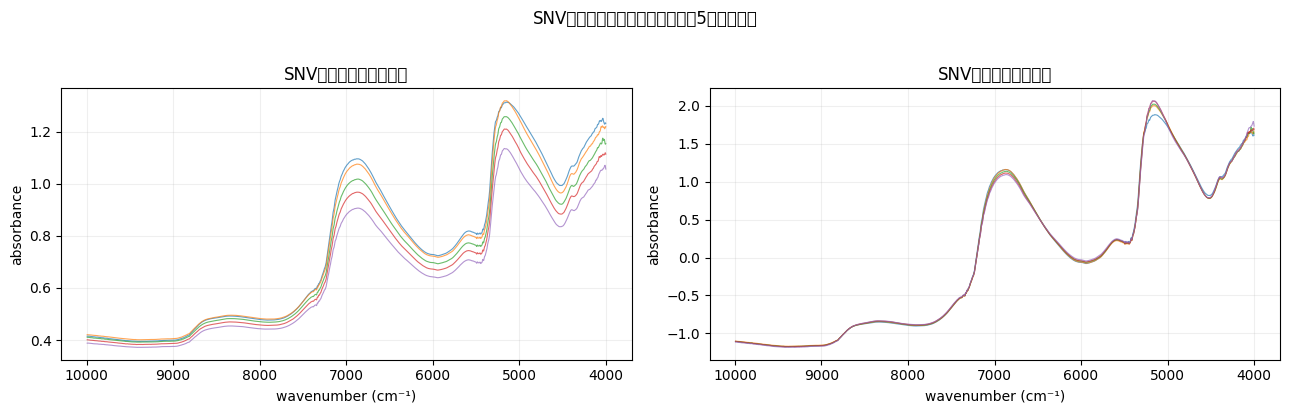

In [6]:
# SNV前後のスペクトルを比較して確認
wavelengths = np.array([float(c) for c in spec_cols])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i in range(min(5, len(train))):
    axes[0].plot(wavelengths, X_train_raw[i], linewidth=0.8, alpha=0.7)
    axes[1].plot(wavelengths, X_train_snv[i], linewidth=0.8, alpha=0.7)

for ax, title in zip(axes, ['SNV前（生スペクトル）', 'SNV後（正規化済み）']):
    ax.invert_xaxis()
    ax.set_title(title)
    ax.set_xlabel('wavenumber (cm⁻¹)')
    ax.set_ylabel('absorbance')
    ax.grid(alpha=0.2)

plt.suptitle('SNV前後のスペクトル比較（先頭5サンプル）', y=1.02)
plt.tight_layout()
plt.show()

## 4. PCA（主成分分析）

**目的**: 1555列の高次元・高相関な特徴量を、情報を保ちつつ少ない次元に圧縮する。

**重要なルール**: PCAは必ず `train` だけで学習（`fit`）し、その変換を `test` にも適用（`transform`）する。
testで `fit` すると「未来のデータを覗き見している」ことになり、スコアが水増しされる（データリーク）。

**次元数の根拠**: EDAの確認で SNV後の累積寄与率が `20次元で99.92%` だったため、20次元を採用する。

PCA 累積寄与率の確認
    5次元: 95.997%
   10次元: 99.256%
   15次元: 99.772%
   20次元: 99.917%
   30次元: 99.982%
   50次元: 99.997%


/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/2702758741.py:20: UserWarning: Glyph 23492 (\N{CJK UNIFIED I

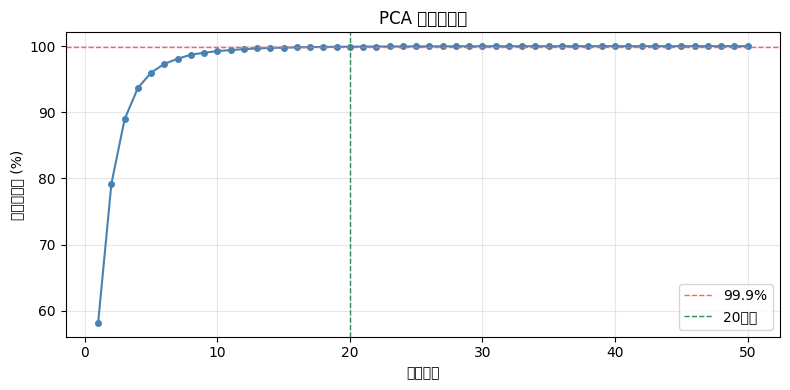

In [7]:
# 寄与率の確認（何次元取れば情報の何%が説明されるか）
pca_check = PCA(n_components=50)
pca_check.fit(X_train_snv)
cumvar = np.cumsum(pca_check.explained_variance_ratio_) * 100

print('PCA 累積寄与率の確認')
for n in [5, 10, 15, 20, 30, 50]:
    print(f'  {n:3d}次元: {cumvar[n-1]:.3f}%')

# 寄与率のグラフ
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 51), cumvar, marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.axhline(99.9, color='tomato', linestyle='--', linewidth=1, label='99.9%')
ax.axvline(20,   color='seagreen', linestyle='--', linewidth=1, label='20次元')
ax.set_xlabel('主成分数')
ax.set_ylabel('累積寄与率 (%)')
ax.set_title('PCA 累積寄与率')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# PCAの学習と適用
N_COMPONENTS = 20  # ← 変えたい場合はここだけ修正

pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train_snv)  # trainで学習して変換
X_test_pca  = pca.transform(X_test_snv)       # 同じ変換をtestに適用

print(f'PCA適用完了（{N_COMPONENTS}次元）')
print(f'X_train_pca: {X_train_pca.shape}')
print(f'X_test_pca:  {X_test_pca.shape}')
print(f'採用した次元での累積寄与率: {cumvar[N_COMPONENTS-1]:.3f}%')

PCA適用完了（20次元）
X_train_pca: (1322, 20)
X_test_pca:  (550, 20)
採用した次元での累積寄与率: 99.917%


## 5. 目的変数のlog変換

**目的**: 含水率の分布が右に偏っているため、log変換で正規分布に近づけてモデルの学習を安定させる。

**`log1p`を使う理由**: `log(0)` はエラーになるが、`log1p(0) = log(1+0) = 0` で安全に処理できる。

**予測後の戻し方**: `expm1(y_pred) = exp(y_pred) - 1` で元のスケールに変換する。

/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_342910/1677334448.py:16: UserWarning: Glyph 21069 (\N{CJK UNIFIED I

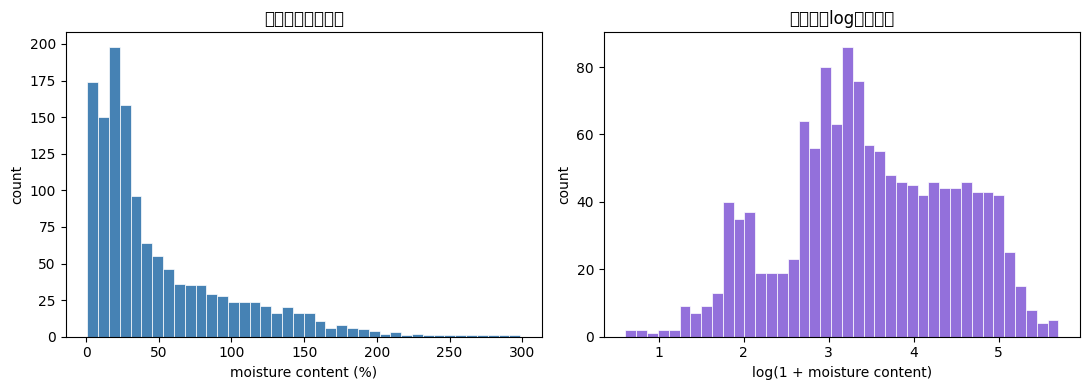

変換前 歪度: 1.649
変換後 歪度: -0.106  （0に近いほど正規分布に近い）


In [9]:
y_train_raw = train['moisture_content'].values
y_train_log = np.log1p(y_train_raw)  # log(1 + 含水率)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_train_raw, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('含水率（変換前）')
axes[0].set_xlabel('moisture content (%)')
axes[0].set_ylabel('count')

axes[1].hist(y_train_log, bins=40, color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[1].set_title('含水率（log変換後）')
axes[1].set_xlabel('log(1 + moisture content)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

print(f'変換前 歪度: {pd.Series(y_train_raw).skew():.3f}')
print(f'変換後 歪度: {pd.Series(y_train_log).skew():.3f}  （0に近いほど正規分布に近い）')

## 6. 前処理済みデータの保存

`models/` フォルダに保存します。`learning.ipynb` と `predicting.ipynb` からこれらを読み込みます。

In [10]:
# PCAオブジェクトの保存（testへの適用に必要）
joblib.dump(pca, 'models/pca.pkl')

# 特徴量・目的変数の保存
np.save('models/X_train.npy', X_train_pca)
np.save('models/y_train.npy', y_train_log)
np.save('models/X_test.npy',  X_test_pca)

# 提出ファイル作成用にsample_numberも保存
np.save('models/test_sample_numbers.npy', test['sample_number'].values)

print('保存完了')
print()
print('保存されたファイル:')
for fname in ['models/pca.pkl', 'models/X_train.npy', 'models/y_train.npy',
              'models/X_test.npy', 'models/test_sample_numbers.npy']:
    size = os.path.getsize(fname)
    print(f'  {fname}  ({size:,} bytes)')

保存完了

保存されたファイル:
  models/pca.pkl  (262,654 bytes)
  models/X_train.npy  (211,648 bytes)
  models/y_train.npy  (10,704 bytes)
  models/X_test.npy  (88,128 bytes)
  models/test_sample_numbers.npy  (4,528 bytes)


## 7. 保存内容の読み込み確認

保存したファイルを実際に読み込んで、形状が正しいかを確認します。

In [11]:
pca_loaded        = joblib.load('models/pca.pkl')
X_train_loaded    = np.load('models/X_train.npy')
y_train_loaded    = np.load('models/y_train.npy')
X_test_loaded     = np.load('models/X_test.npy')
test_ids_loaded   = np.load('models/test_sample_numbers.npy')

print('読み込み確認')
print(f'X_train: {X_train_loaded.shape}  期待値: (1322, {N_COMPONENTS})')
print(f'y_train: {y_train_loaded.shape}  期待値: (1322,)')
print(f'X_test:  {X_test_loaded.shape}   期待値: (550,  {N_COMPONENTS})')
print(f'test_ids:{test_ids_loaded.shape} 期待値: (550,)')
print()
print('前処理パイプライン完了。次は learning.ipynb に進んでください。')

読み込み確認
X_train: (1322, 20)  期待値: (1322, 20)
y_train: (1322,)  期待値: (1322,)
X_test:  (550, 20)   期待値: (550,  20)
test_ids:(550,) 期待値: (550,)

前処理パイプライン完了。次は learning.ipynb に進んでください。
